In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [20]:
data_x = np.load("X.npy")
data_y = np.load("Y.npy")

Problem 5_1

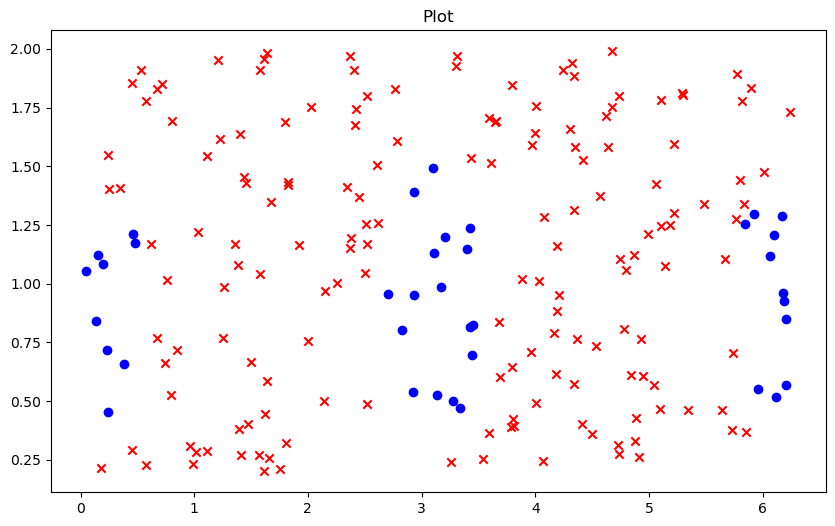

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(data_x[data_y == 0, 0], data_x[data_y == 0, 1], c = 'r', marker = 'x')
plt.scatter(data_x[data_y == 1, 0], data_x[data_y == 1, 1], c = 'b', marker = 'o')
plt.title("Plot")
plt.show()

Problem 5_2

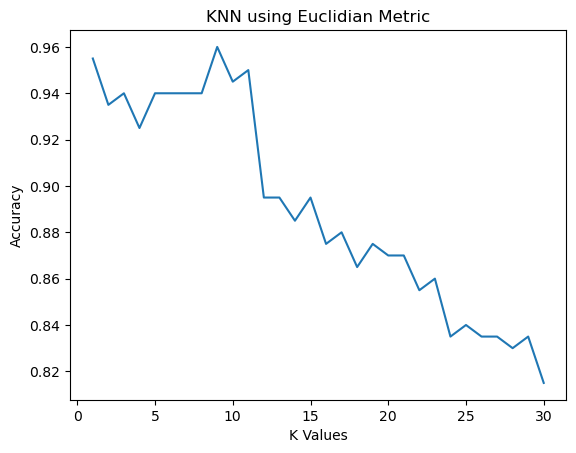

In [22]:
k_values = np.array([i for i in range(1,31)])
accuracy_values = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(data_x,data_y)
    accuracy_values.append(cross_val_score(knn, data_x, data_y, cv = 5).mean())

plt.plot(k_values, accuracy_values)
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("KNN using Euclidian Metric")
plt.show()

Problem 5_3

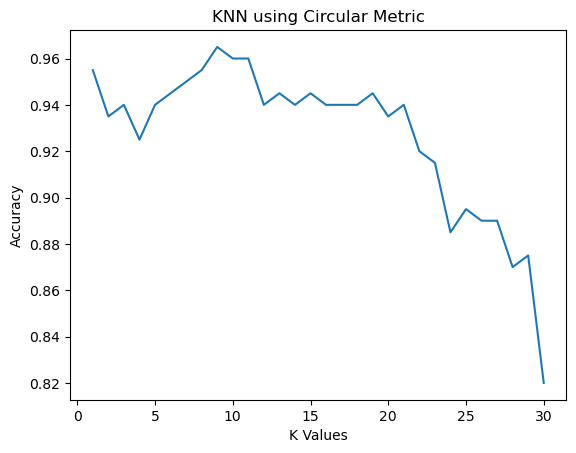

In [23]:
def circular_metric(x1,x2):
    return min(abs(x1-x2), 2*math.pi-abs(x1-x2))

def dist(x1,x2):
    return math.sqrt(pow(circular_metric(x1[0],x2[0]),2)+pow(abs(x1[1]-x2[1]),2))

k_values = np.array([i for i in range(1,31)])
accuracy_values_c = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric=dist)
    knn.fit(data_x,data_y)
    accuracy_values_c.append(cross_val_score(knn, data_x, data_y, cv = 5).mean())

plt.plot(k_values, accuracy_values_c)
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("KNN using Circular Metric")
plt.show()

Problem 5_4


In [24]:
def stats(x1, n1):
    print(f"Test {n1}")
    arr = np.array(x1)
    print(f"K-value: {np.argmax(arr) + 1}") 
    print(f"Accuracy: {np.max(arr)}")
    

stats(accuracy_values,1)
stats(accuracy_values_c,2)

    

Test 1
K-value: 9
Accuracy: 0.96
Test 2
K-value: 9
Accuracy: 0.9650000000000001


Problem 5_5


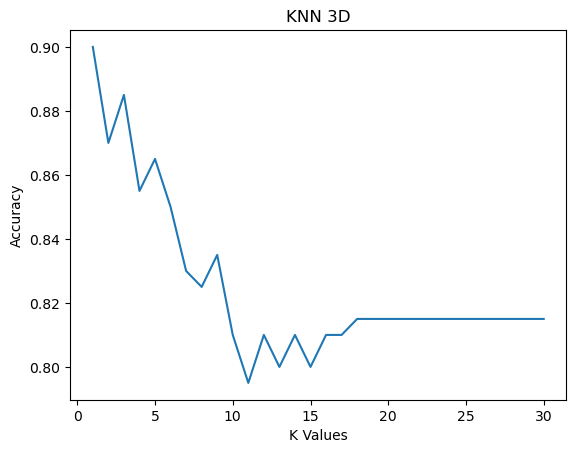

Test 1
K-value: 9
Accuracy: 0.96
Test 2
K-value: 9
Accuracy: 0.9650000000000001
Test 3
K-value: 1
Accuracy: 0.9


In [29]:
def dist_3d(x1,x2):
    return math.sqrt(pow(circular_metric(x1[0],x2[0]),2)+pow(abs(x1[1]-x2[1]),2)+pow(circular_metric(x1[2],x2[2]),2))

k_values = np.array([i for i in range(1,31)])
accuracy_values_3d_c = []
x3 = np.array([[np.random.uniform(0, 2*math.pi)] for i in range(0, data_x.shape[0])])
#combine
data_x13 = np.concatenate((data_x, x3), axis=1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric=dist_3d)
    knn.fit(data_x13,data_y)
    accuracy_values_3d_c.append(cross_val_score(knn, data_x13, data_y, cv = 5).mean())
plt.plot(k_values, accuracy_values_3d_c)

plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("KNN 3D")
plt.show()

stats(accuracy_values,1)
stats(accuracy_values_c,2)
stats(accuracy_values_3d_c,3)
